# Logistic Regression — Step-by-Step



[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davidrajm/DSA-DL-FDP/blob/main/Day%2002%20-%20Machine%20Learning%20-%20Dr%20Arun%20RajKumar/Lab%20Sessions/04_logistic_regression.ipynb)


Logistic Regression predicts the **probability** that an input belongs to a class, using the sigmoid function to squash output between 0 and 1.

$$P(y=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n)}}$$

---
## Step 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("All libraries imported successfully.")

All libraries imported successfully.


---
## Step 2 — Plot Helper Functions

In [2]:
def plot_target_distribution(series, class_names, title='Class Distribution'):
    """Bar chart of class counts."""
    counts = pd.Series(series).value_counts().sort_index()
    plt.figure(figsize=(7, 4))
    bars = plt.bar(class_names, counts.values, color=['steelblue', 'tomato'],
                   edgecolor='white', width=0.5)
    for bar, val in zip(bars, counts.values):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(val), ha='center', fontsize=11)
    plt.title(title, fontweight='bold')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
    print(f"Class balance: {dict(zip(class_names, counts.values))}")


def plot_correlation_heatmap(df, title='Correlation Matrix'):
    """Lower-triangle heatmap of the full correlation matrix."""
    corr = df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(16, 12))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                mask=mask, linewidths=0.3, square=True,
                annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_feature_target_correlation(df, target_col='target', top_n=15, threshold=0.3):
    """Top-N features by absolute correlation with the target."""
    target_corr = (df.corr()[target_col]
                     .drop(target_col)
                     .reindex(df.corr()[target_col].drop(target_col)
                     .abs().sort_values(ascending=False).index))
    target_corr = target_corr.head(top_n).sort_values()
    colors = ['tomato' if v < 0 else 'steelblue' for v in target_corr.values]

    plt.figure(figsize=(10, 6))
    bars = plt.barh(target_corr.index, target_corr.values,
                    color=colors, edgecolor='white', height=0.6)
    plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
    plt.axvline( threshold, color='green', linewidth=1, linestyle=':',
                alpha=0.7, label=f'|r| = {threshold} threshold')
    plt.axvline(-threshold, color='green', linewidth=1, linestyle=':', alpha=0.7)
    plt.xlabel('Pearson Correlation with Target')
    plt.title(f'Top {top_n} Features by Correlation with {target_col}', fontweight='bold')
    plt.legend()
    for bar, val in zip(bars, target_corr.values):
        plt.text(val + 0.01 * np.sign(val),
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=9)
    plt.tight_layout()
    plt.show()
    return target_corr


def plot_confusion_matrix(y_true, y_pred, class_names, title='Confusion Matrix'):
    """Annotated heatmap confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5)
    plt.ylabel('Actual', fontweight='bold')
    plt.xlabel('Predicted', fontweight='bold')
    plt.title(title, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_roc_curve(y_true, y_prob, title='ROC Curve'):
    """ROC curve with AUC score annotated."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
    plt.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title, fontweight='bold')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    return roc_auc


def plot_precision_recall_curve(y_true, y_prob, title='Precision-Recall Curve'):
    """Precision-Recall curve with average precision annotated."""
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    plt.figure(figsize=(7, 6))
    plt.plot(recall, precision, color='darkorange', linewidth=2,
             label=f'AP = {ap:.3f}')
    plt.fill_between(recall, precision, alpha=0.08, color='darkorange')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title, fontweight='bold')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    return ap


def plot_coefficients(feature_names, coefficients, title='Logistic Regression Coefficients', top_n=20):
    """Top-N coefficients by absolute value, colored by sign."""
    coef_df = pd.DataFrame({'Feature': feature_names,
                             'Coefficient': coefficients})
    coef_df = (coef_df.reindex(coef_df['Coefficient'].abs()
                .sort_values(ascending=False).index)
                .head(top_n)
                .sort_values('Coefficient'))
    colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

    plt.figure(figsize=(10, max(5, len(coef_df) * 0.4)))
    bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'],
                    color=colors, edgecolor='white', height=0.6)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel('Coefficient Value')
    plt.title(title, fontweight='bold')
    for bar, val in zip(bars, coef_df['Coefficient']):
        plt.text(val + 0.02 * np.sign(val),
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=9)
    plt.tight_layout()
    plt.show()
    return coef_df


print("Plot helper functions defined.")

Plot helper functions defined.


---
## Step 3 — Load Dataset

569 samples, 30 features, binary target: malignant (0) vs benign (1).

In [3]:
dataset = load_breast_cancer()

df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target

print(f"Shape          : {df.shape}")
print(f"Features       : {list(dataset.feature_names)}")
print(f"Classes        : {list(dataset.target_names)}")
df.head()

Shape          : (569, 31)
Features       : [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]
Classes        : [np.str_('malignant'), np.str_('benign')]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---
## Step 4 — EDA

Check class balance, feature correlations, and which features are most predictive of the target.

In [4]:
df.describe().round(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,0.627
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,0.484
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,1.000
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,1.000
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208,1.000


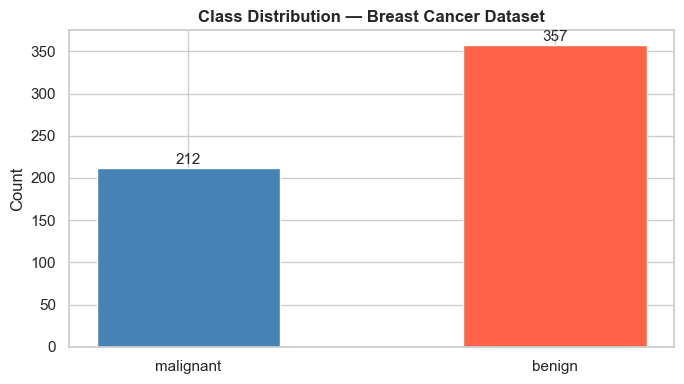

Class balance: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


In [5]:
plot_target_distribution(df['target'],
                         class_names=list(dataset.target_names),
                         title='Class Distribution — Breast Cancer Dataset')

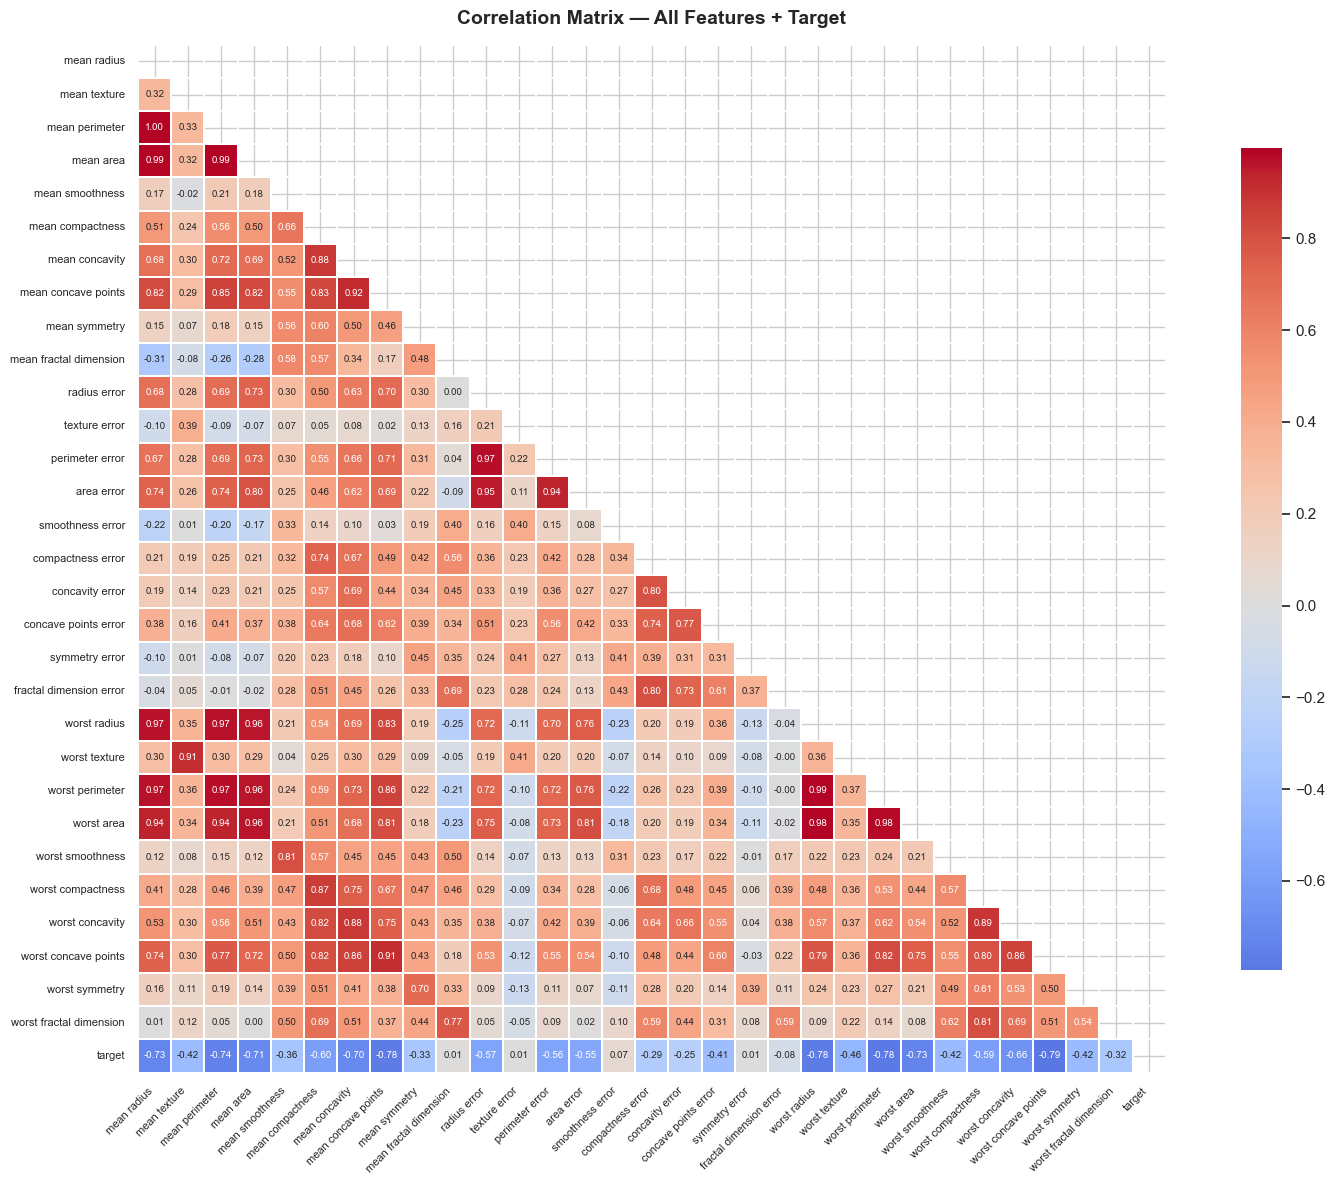

In [6]:
plot_correlation_heatmap(df, title='Correlation Matrix — All Features + Target')

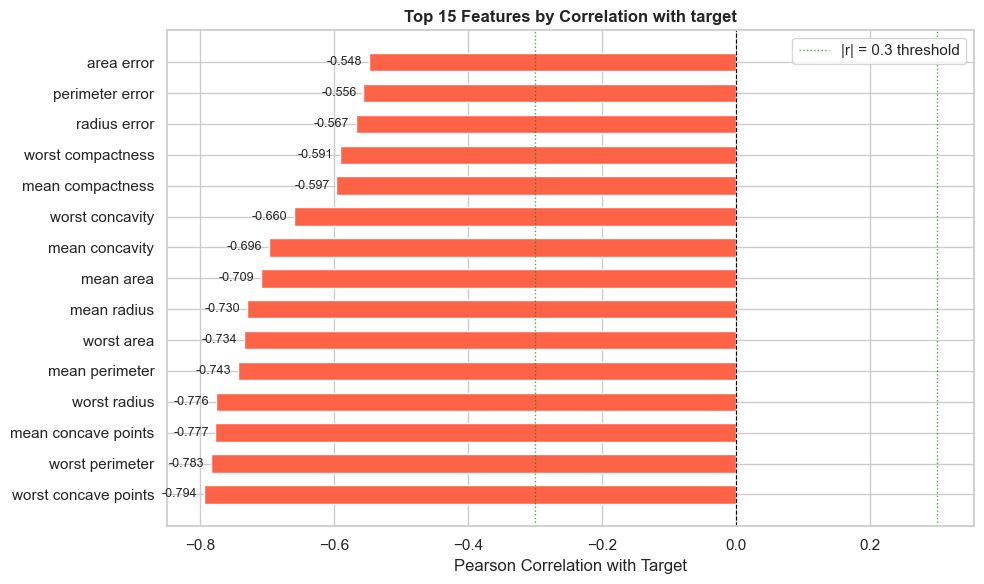

In [7]:
target_corr = plot_feature_target_correlation(df, target_col='target', top_n=15, threshold=0.3)

---
## Step 5 — Prepare Features and Target

In [8]:
X = df.drop(columns='target')
y = df['target']

print(f"Feature matrix X : {X.shape}")
print(f"Target vector y  : {y.shape}")

Feature matrix X : (569, 30)
Target vector y  : (569,)


---
## Step 6 — Scale Features

Logistic Regression is sensitive to feature scale — StandardScaler brings all features to mean=0, std=1.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Mean after scaling  (should be ~0) : {X_scaled.mean(axis=0).round(6)}")
print(f"Std  after scaling  (should be ~1) : {X_scaled.std(axis=0).round(6)}")

Mean after scaling  (should be ~0) : [-0.  0. -0. -0. -0.  0.  0. -0.  0.  0.  0. -0. -0. -0. -0.  0.  0.  0.
  0. -0. -0.  0. -0.  0. -0. -0.  0.  0.  0. -0.]
Std  after scaling  (should be ~1) : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


---
## Step 7 — Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserve class ratio in both splits
)

print(f"Training set : {X_train.shape[0]} samples  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]}  samples  ({X_test.shape[0]/len(X)*100:.0f}%)")

Training set : 455 samples  (80%)
Test set     : 114  samples  (20%)


---
## Step 8 — Fit the Model

In [13]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]   # probability of positive class

print("Model trained successfully.")
print(f"Intercept (\u03b2\u2080) : {model.intercept_[0]:.4f}")

Model trained successfully.
Intercept (β₀) : 0.1659


---
## Step 9 — Metrics

Accuracy alone is not enough for classification — always look at precision, recall, and F1 per class.

In [14]:
def compute_metrics(y_true, y_pred, y_prob, label):
    """Return a dict of key classification metrics."""
    from sklearn.metrics import f1_score, precision_score, recall_score
    return {
        'Set'       : label,
        'Accuracy'  : accuracy_score(y_true, y_pred),
        'Precision' : precision_score(y_true, y_pred),
        'Recall'    : recall_score(y_true, y_pred),
        'F1'        : f1_score(y_true, y_pred),
        'ROC-AUC'   : auc(*roc_curve(y_true, y_prob)[:2]),
    }

y_pred_train       = model.predict(X_train)
y_pred_proba_train = model.predict_proba(X_train)[:, 1]

results = pd.DataFrame([
    compute_metrics(y_train, y_pred_train, y_pred_proba_train, 'Train Set (80%)'),
    compute_metrics(y_test,  y_pred,       y_pred_proba,       'Test Set  (20%)'),
]).set_index('Set').round(4)

print(results.to_string())
print()
print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=dataset.target_names))

                 Accuracy  Precision  Recall      F1  ROC-AUC
Set                                                          
Train Set (80%)    0.9890     0.9861  0.9965  0.9913   0.9974
Test Set  (20%)    0.9825     0.9861  0.9861  0.9861   0.9954

Classification Report (Test Set):
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



---
## Step 10 — Confusion Matrix

Shows exactly where the model is making errors — false positives vs false negatives.

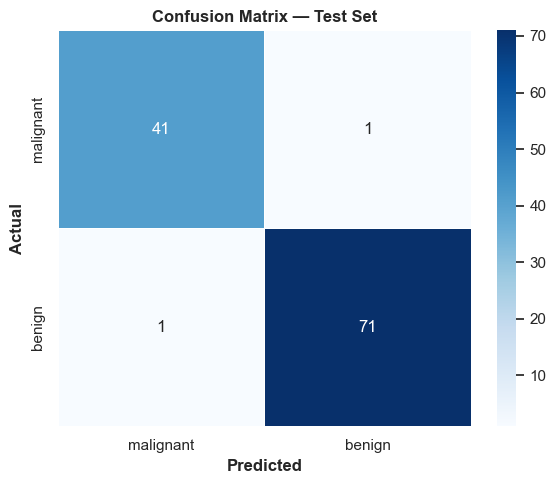

In [15]:
plot_confusion_matrix(y_test, y_pred,
                      class_names=list(dataset.target_names),
                      title='Confusion Matrix — Test Set')

---
## Step 11 — ROC Curve

AUC closer to 1.0 means the model separates the two classes well.

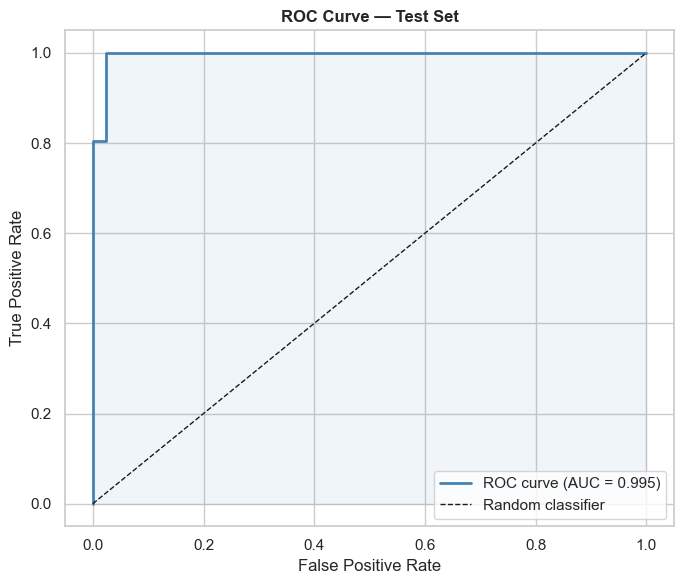

AUC : 0.9954


In [16]:
roc_auc = plot_roc_curve(y_test, y_pred_proba, title='ROC Curve — Test Set')
print(f"AUC : {roc_auc:.4f}")

---
## Step 12 — Precision-Recall Curve

More informative than ROC when classes are imbalanced.

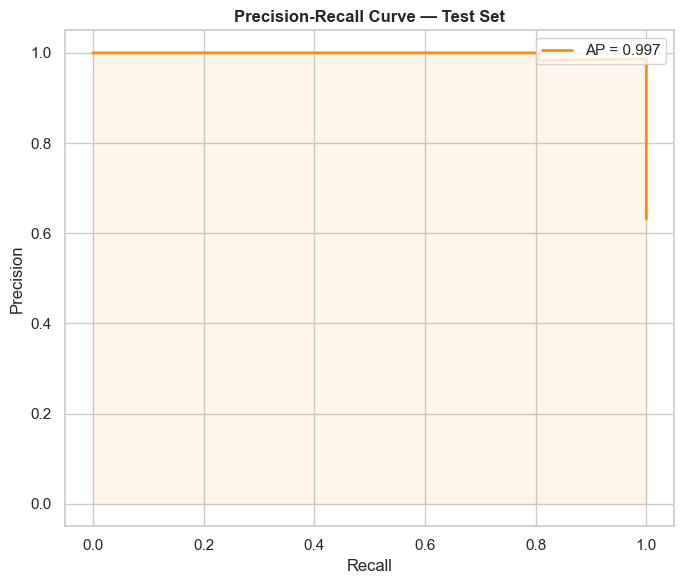

Average Precision : 0.9971


In [17]:
ap = plot_precision_recall_curve(y_test, y_pred_proba,
                                 title='Precision-Recall Curve — Test Set')
print(f"Average Precision : {ap:.4f}")

---
## Step 13 — Coefficients

Positive coefficient — feature pushes toward benign (1). Negative — pushes toward malignant (0).

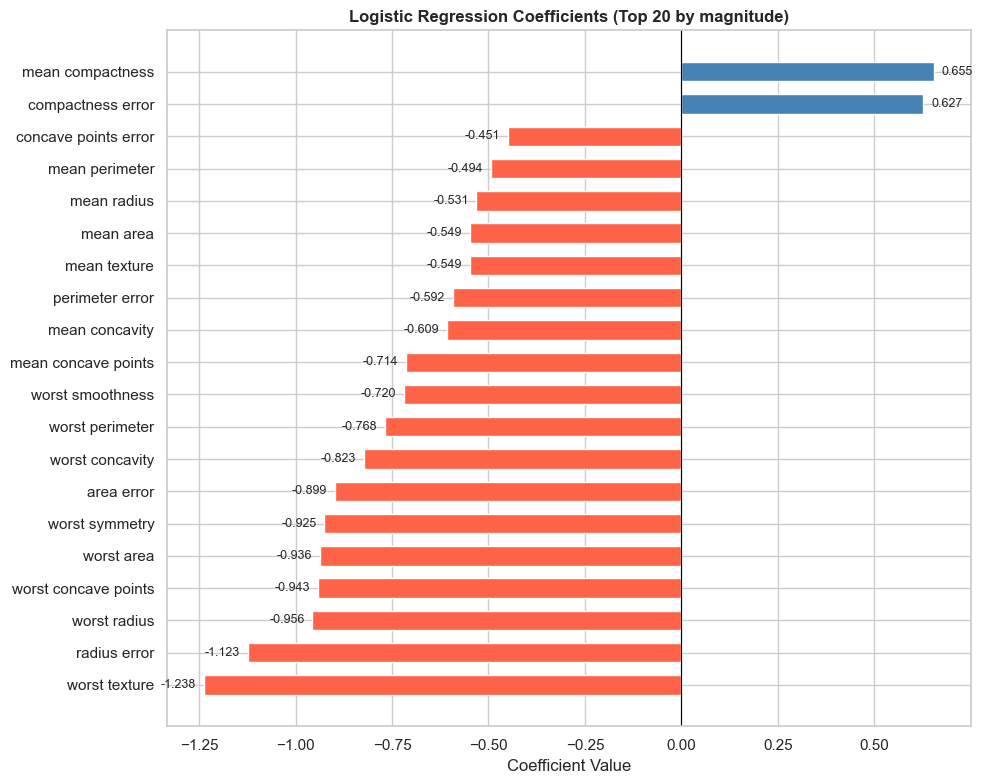

In [18]:
coef_df = plot_coefficients(
    feature_names=dataset.feature_names,
    coefficients=model.coef_[0],
    title='Logistic Regression Coefficients (Top 20 by magnitude)',
    top_n=20
)

---
## Final Summary

| Step | What | Note |
|------|------|------|
| 1 | Imports | Added sklearn metrics for classification |
| 2 | Plot helpers | All plotting logic in one place |
| 3 | Load dataset | `dataset.data`, `dataset.feature_names`, `dataset.target` |
| 4 | EDA | Class balance, correlation heatmap, top features |
| 5 | Prepare X, y | Same pattern as linear regression |
| 6 | Scale features | Required for logistic regression — unlike tree models |
| 7 | Train-test split | `stratify=y` ensures class ratio is preserved |
| 8 | Fit model | `predict_proba` gives probabilities, not just class labels |
| 9 | Metrics | Accuracy, Precision, Recall, F1, ROC-AUC |
| 10 | Confusion matrix | See exact error types |
| 11 | ROC curve | Overall class separation ability |
| 12 | Precision-Recall | Better metric when classes are imbalanced |
| 13 | Coefficients | Feature importance and direction |